# Spherical cuboid P2M and L2P comparison against exact direct

This notebook independently switches the source and target far-field representations, producing four spherical FMM cases: point-dipole or finite-cuboid P2M crossed with point or volume-averaged cuboid L2P. Source and target geometry remain `UNIFORM_CUBOID -> VOLUME_AVERAGED_CUBOID` in every case, so list1 P2P always uses the same exact cuboid-to-cuboid tensor and retains every finite self-field. The exact dense cuboid-to-cuboid field is the common reference.


In [1]:
import time

import cdfmm
import matplotlib.pyplot as plt
import numpy as np

SIDE = 10.0e-9
SPACING = 3.0 * SIDE
SHAPE = (15, 15, 15)
ORDERS = [4, 6]
TREE_DEPTHS = [2, 3, 4, 5]
REPEATS = 1
CASES = [
    dict(
        label="point P2M + point L2P",
        use_cuboid_p2m=False,
        use_cuboid_l2p=False,
        linestyle=":",
        marker="o",
    ),
    dict(
        label="cuboid P2M + point L2P",
        use_cuboid_p2m=True,
        use_cuboid_l2p=False,
        linestyle="--",
        marker="s",
    ),
    dict(
        label="point P2M + cuboid L2P",
        use_cuboid_p2m=False,
        use_cuboid_l2p=True,
        linestyle="-.",
        marker="^",
    ),
    dict(
        label="cuboid P2M + cuboid L2P",
        use_cuboid_p2m=True,
        use_cuboid_l2p=True,
        linestyle="-",
        marker="D",
    ),
]

if not cdfmm.cuda_full_available():
    raise RuntimeError(
        "This notebook requires a CUDA-enabled build and an available GPU: "
        f"{cdfmm.cuda_device_description()}"
    )

indices = np.indices(SHAPE, dtype=float).reshape(3, -1).T
centres = (indices - (np.asarray(SHAPE) - 1) / 2) * SPACING
phase = np.arange(len(centres), dtype=float)
magnetisations = np.column_stack((
    7.0e5 + 1.5e5 * np.sin(0.17 * phase),
    -3.0e5 + 2.0e5 * np.cos(0.11 * phase),
    4.0e5 * np.sin(0.07 * phase + 0.3),
))
cube = cdfmm.CuboidSize(SIDE, SIDE, SIDE)
moments = np.ascontiguousarray(SIDE**3 * magnetisations)


## Exact reusable cuboid-to-cuboid reference

Construction and repeated evaluation are timed separately. The dense tensor maps each uniformly magnetised source cuboid to the analytically volume-averaged field in each receiving cuboid. No target-to-source identity map is supplied because cuboid self-fields are finite and physical.


In [2]:
start = time.perf_counter()
direct = cdfmm.DenseDirectPlan(
    source_positions=centres,
    target_positions=centres,
    source_geometry=cdfmm.SourceGeometry.UNIFORM_CUBOID,
    target_geometry=cdfmm.TargetGeometry.VOLUME_AVERAGED_CUBOID,
    source_sizes=[cube],
    target_sizes=[cube],
    static_precision="float64",
)
direct_initialisation_s = time.perf_counter() - start
direct.evaluate(moments, backend=cdfmm.DenseDirectBackend.PORTABLE)
samples = []
for _ in range(REPEATS):
    start = time.perf_counter()
    H_direct = direct.evaluate(
        moments,
        backend=cdfmm.DenseDirectBackend.PORTABLE,
    )
    samples.append(time.perf_counter() - start)
direct_evaluation_s = float(np.median(samples))
print(f"Dense construction: {direct_initialisation_s:.6f} s")
print(f"Dense evaluation:   {direct_evaluation_s:.6f} s")


Dense construction: 238.999666 s
Dense evaluation:   0.059671 s


## Independent P2M and L2P comparison

`use_cuboid_p2m` changes only the upward leaf operator. `use_cuboid_l2p` changes only the far-field target evaluator. `target_geometry` remains volume-averaged cuboid throughout, which keeps exact cuboid-to-cuboid list1 P2P identical across all four cases.


In [3]:
rows = []
reference_norms = np.linalg.norm(H_direct, axis=1)
meaningful = reference_norms > 1.0e-12 * reference_norms.max()
for depth in TREE_DEPTHS:
    for case in CASES:
        for order in ORDERS:
            options = cdfmm.UniformFmmOptions()
            options.expansion_basis = cdfmm.ExpansionBasis.SPHERICAL
            options.precision = cdfmm.StaticPrecision.FLOAT64
            options.expansion_order = order
            options.tree.max_level = depth
            options.source_geometry = cdfmm.SourceGeometry.UNIFORM_CUBOID
            options.source_sizes = [cube]
            options.target_geometry = (
                cdfmm.TargetGeometry.VOLUME_AVERAGED_CUBOID
            )
            options.target_sizes = [cube]
            options.use_cuboid_p2m = case["use_cuboid_p2m"]
            options.use_cuboid_l2p = case["use_cuboid_l2p"]
            options.backend = cdfmm.ExecutionBackend.CUDA_FULL

            start = time.perf_counter()
            fmm = cdfmm.UniformFmm(centres, centres, options)
            initialisation_s = time.perf_counter() - start
            fmm.evaluate(moments)
            samples = []
            for _ in range(REPEATS):
                start = time.perf_counter()
                H_fmm = fmm.evaluate(moments)["H"]
                samples.append(time.perf_counter() - start)

            difference = H_fmm - H_direct
            absolute = np.linalg.norm(difference, axis=1)
            rows.append(dict(
                case=case["label"],
                use_cuboid_p2m=case["use_cuboid_p2m"],
                use_cuboid_l2p=case["use_cuboid_l2p"],
                depth=depth,
                order=order,
                initialisation_s=initialisation_s,
                evaluation_s=float(np.median(samples)),
                relative_l2=float(
                    np.linalg.norm(difference) / np.linalg.norm(H_direct)
                ),
                maximum_absolute=float(absolute.max()),
                maximum_pointwise_relative=float(
                    np.max(absolute[meaningful] / reference_norms[meaningful])
                ),
            ))

for row in rows:
    print(row)


{'case': 'point P2M + point L2P', 'use_cuboid_p2m': False, 'use_cuboid_l2p': False, 'depth': 2, 'order': 4, 'initialisation_s': 55.149266773005365, 'evaluation_s': 0.0015093449910636991, 'relative_l2': 0.00016392277665228704, 'maximum_absolute': 205.90318679867585, 'maximum_pointwise_relative': 0.0008486515131219496}
{'case': 'point P2M + point L2P', 'use_cuboid_p2m': False, 'use_cuboid_l2p': False, 'depth': 2, 'order': 6, 'initialisation_s': 64.44708275700395, 'evaluation_s': 0.0016111470031319186, 'relative_l2': 2.6767347733013377e-05, 'maximum_absolute': 46.716292444299064, 'maximum_pointwise_relative': 0.0001834087271778525}
{'case': 'cuboid P2M + point L2P', 'use_cuboid_p2m': True, 'use_cuboid_l2p': False, 'depth': 2, 'order': 4, 'initialisation_s': 55.4064468209981, 'evaluation_s': 0.001538197000627406, 'relative_l2': 0.00016392277665228694, 'maximum_absolute': 205.90318679867235, 'maximum_pointwise_relative': 0.0008486515131219496}
{'case': 'cuboid P2M + point L2P', 'use_cuboid_

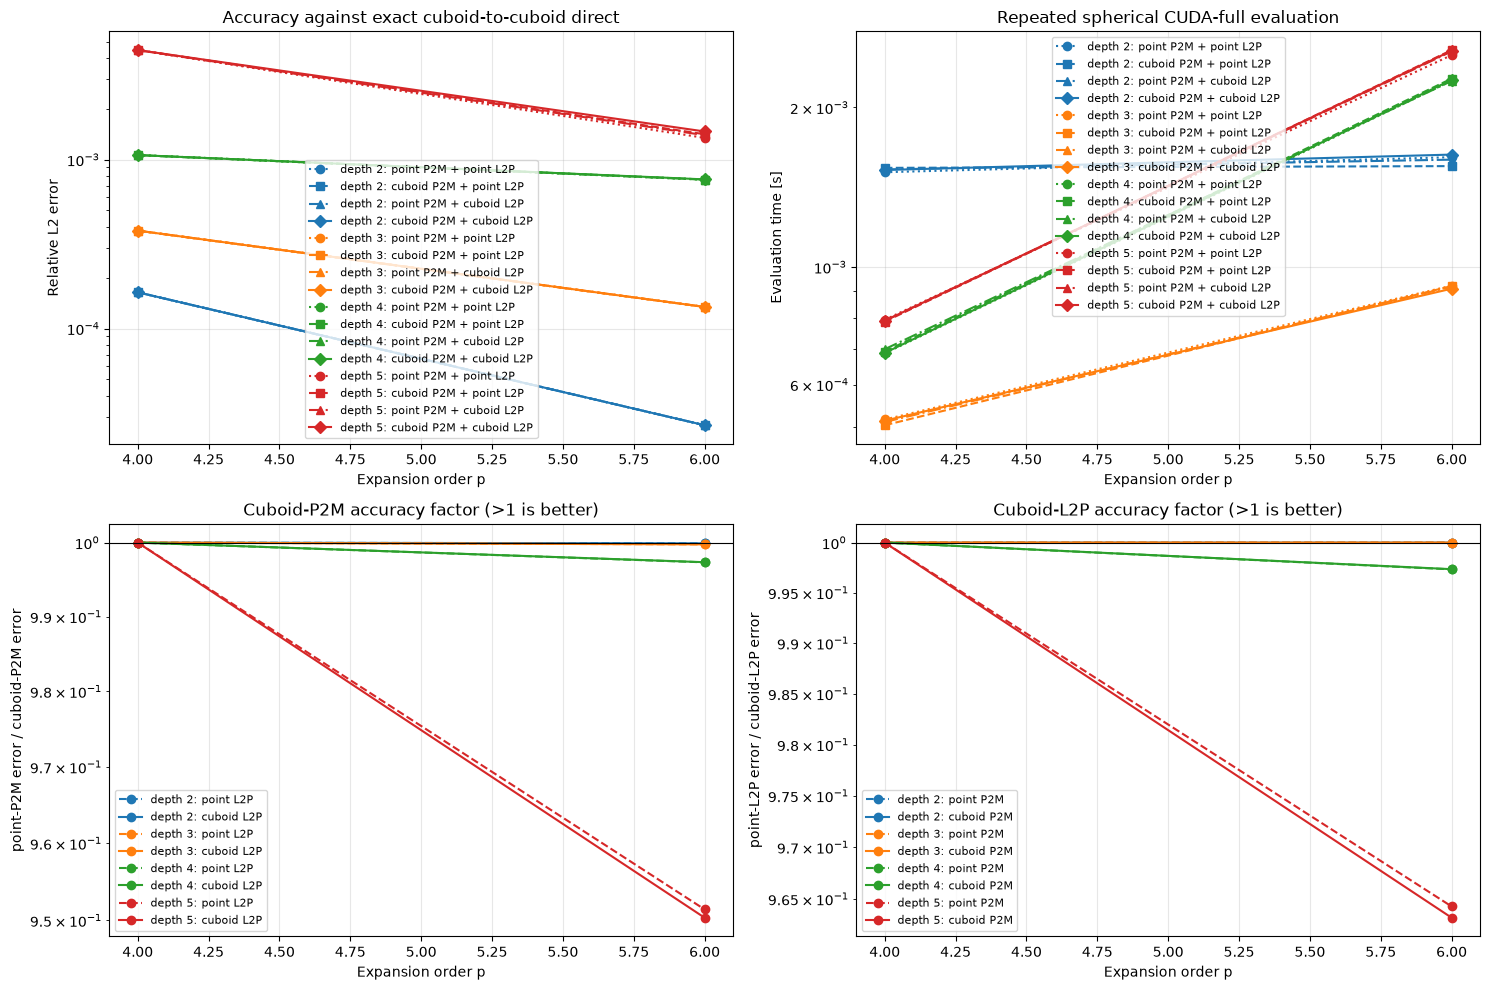

In [4]:
def select_rows(depth, use_cuboid_p2m, use_cuboid_l2p):
    return [
        row for row in rows
        if row["depth"] == depth
        and row["use_cuboid_p2m"] == use_cuboid_p2m
        and row["use_cuboid_l2p"] == use_cuboid_l2p
    ]


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for depth_index, depth in enumerate(TREE_DEPTHS):
    colour = f"C{depth_index}"
    for case in CASES:
        selected = select_rows(
            depth,
            case["use_cuboid_p2m"],
            case["use_cuboid_l2p"],
        )
        orders = [row["order"] for row in selected]
        errors = [row["relative_l2"] for row in selected]
        times = [row["evaluation_s"] for row in selected]
        label = f"depth {depth}: {case['label']}"
        axes[0, 0].semilogy(
            orders, errors, marker=case["marker"],
            linestyle=case["linestyle"], color=colour, label=label,
        )
        axes[0, 1].semilogy(
            orders, times, marker=case["marker"],
            linestyle=case["linestyle"], color=colour, label=label,
        )

    for use_cuboid_l2p in (False, True):
        point_p2m = select_rows(depth, False, use_cuboid_l2p)
        cuboid_p2m = select_rows(depth, True, use_cuboid_l2p)
        p2m_factor = np.asarray([
            row["relative_l2"] for row in point_p2m
        ]) / np.maximum(
            [row["relative_l2"] for row in cuboid_p2m],
            np.finfo(float).tiny,
        )
        l2p_label = "cuboid L2P" if use_cuboid_l2p else "point L2P"
        axes[1, 0].semilogy(
            ORDERS, p2m_factor, marker="o",
            linestyle="-" if use_cuboid_l2p else "--",
            color=colour, label=f"depth {depth}: {l2p_label}",
        )

    for use_cuboid_p2m in (False, True):
        point_l2p = select_rows(depth, use_cuboid_p2m, False)
        cuboid_l2p = select_rows(depth, use_cuboid_p2m, True)
        l2p_factor = np.asarray([
            row["relative_l2"] for row in point_l2p
        ]) / np.maximum(
            [row["relative_l2"] for row in cuboid_l2p],
            np.finfo(float).tiny,
        )
        p2m_label = "cuboid P2M" if use_cuboid_p2m else "point P2M"
        axes[1, 1].semilogy(
            ORDERS, l2p_factor, marker="o",
            linestyle="-" if use_cuboid_p2m else "--",
            color=colour, label=f"depth {depth}: {p2m_label}",
        )

axes[0, 0].set(
    xlabel="Expansion order p", ylabel="Relative L2 error",
    title="Accuracy against exact cuboid-to-cuboid direct",
)
axes[0, 1].set(
    xlabel="Expansion order p", ylabel="Evaluation time [s]",
    title="Repeated spherical CUDA-full evaluation",
)
axes[1, 0].axhline(1.0, color="black", linewidth=0.8)
axes[1, 0].set(
    xlabel="Expansion order p",
    ylabel="point-P2M error / cuboid-P2M error",
    title="Cuboid-P2M accuracy factor (>1 is better)",
)
axes[1, 1].axhline(1.0, color="black", linewidth=0.8)
axes[1, 1].set(
    xlabel="Expansion order p",
    ylabel="point-L2P error / cuboid-L2P error",
    title="Cuboid-L2P accuracy factor (>1 is better)",
)
for axis in axes.flat:
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Scope

All four cases use spherical far-field expansions, FP64 arithmetic, the full CUDA backend, uniform-cuboid sources, volume-averaged cuboid target geometry, and exact cuboid-to-cuboid P2P. The two comparison flags alter only P2M and L2P, respectively. This isolates finite source and receiving-volume corrections without changing near-field physics.

In the recorded 10 nm cube, 30 nm spacing run, all four order-4 results are identical to displayed precision. At order 6, cuboid P2M and cuboid L2P provide no accuracy gain and slightly increase the measured error, with the largest difference at depth 5. This is a result for the tested low orders and centred cubes, whose first physical shape correction is degree five; it is not a general claim for non-cubic cells or higher orders.
